In [1]:
import sys
sys.path.append('..')

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from keras.optimizers import SGD
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.losses import MeanSquaredError

from utils.log import log_loss

2023-07-29 12:00:11.775417: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


# 1. Prepare data

In [3]:
df = pd.read_csv('demand_forecasting_dataset/train.csv')
df

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


## Analyze data

In [4]:
len(df.date.unique())

1826

In [5]:
f'Min date from train set: {df.date.min()}'


'Min date from train set: 2013-01-01'

In [6]:
f'Max date from train set: {df.date.max()}'

'Max date from train set: 2017-12-31'

In [7]:
df.store.unique(), len(df.store.unique())

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), 10)

In [8]:
df.item.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])

In [9]:
df

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


## Visualize data

In [10]:
def visualize_sales_date(data):
    plt.figure(figsize=(30,10))
    sns.lineplot(
        data=data.sample(frac=0.5).sort_index(),
        x='date',
        y='sales'
    )
    plt.show()

In [11]:
daily_sales_df = df.groupby('date', as_index=False).sales.sum()
daily_sales_df

,date,sales
0,2013-01-01,13696
1,2013-01-02,13678
2,2013-01-03,14488
3,2013-01-04,15677
4,2013-01-05,16237
...,...,...
1821,2017-12-27,20378
1822,2017-12-28,21885
1823,2017-12-29,23535
1824,2017-12-30,24988


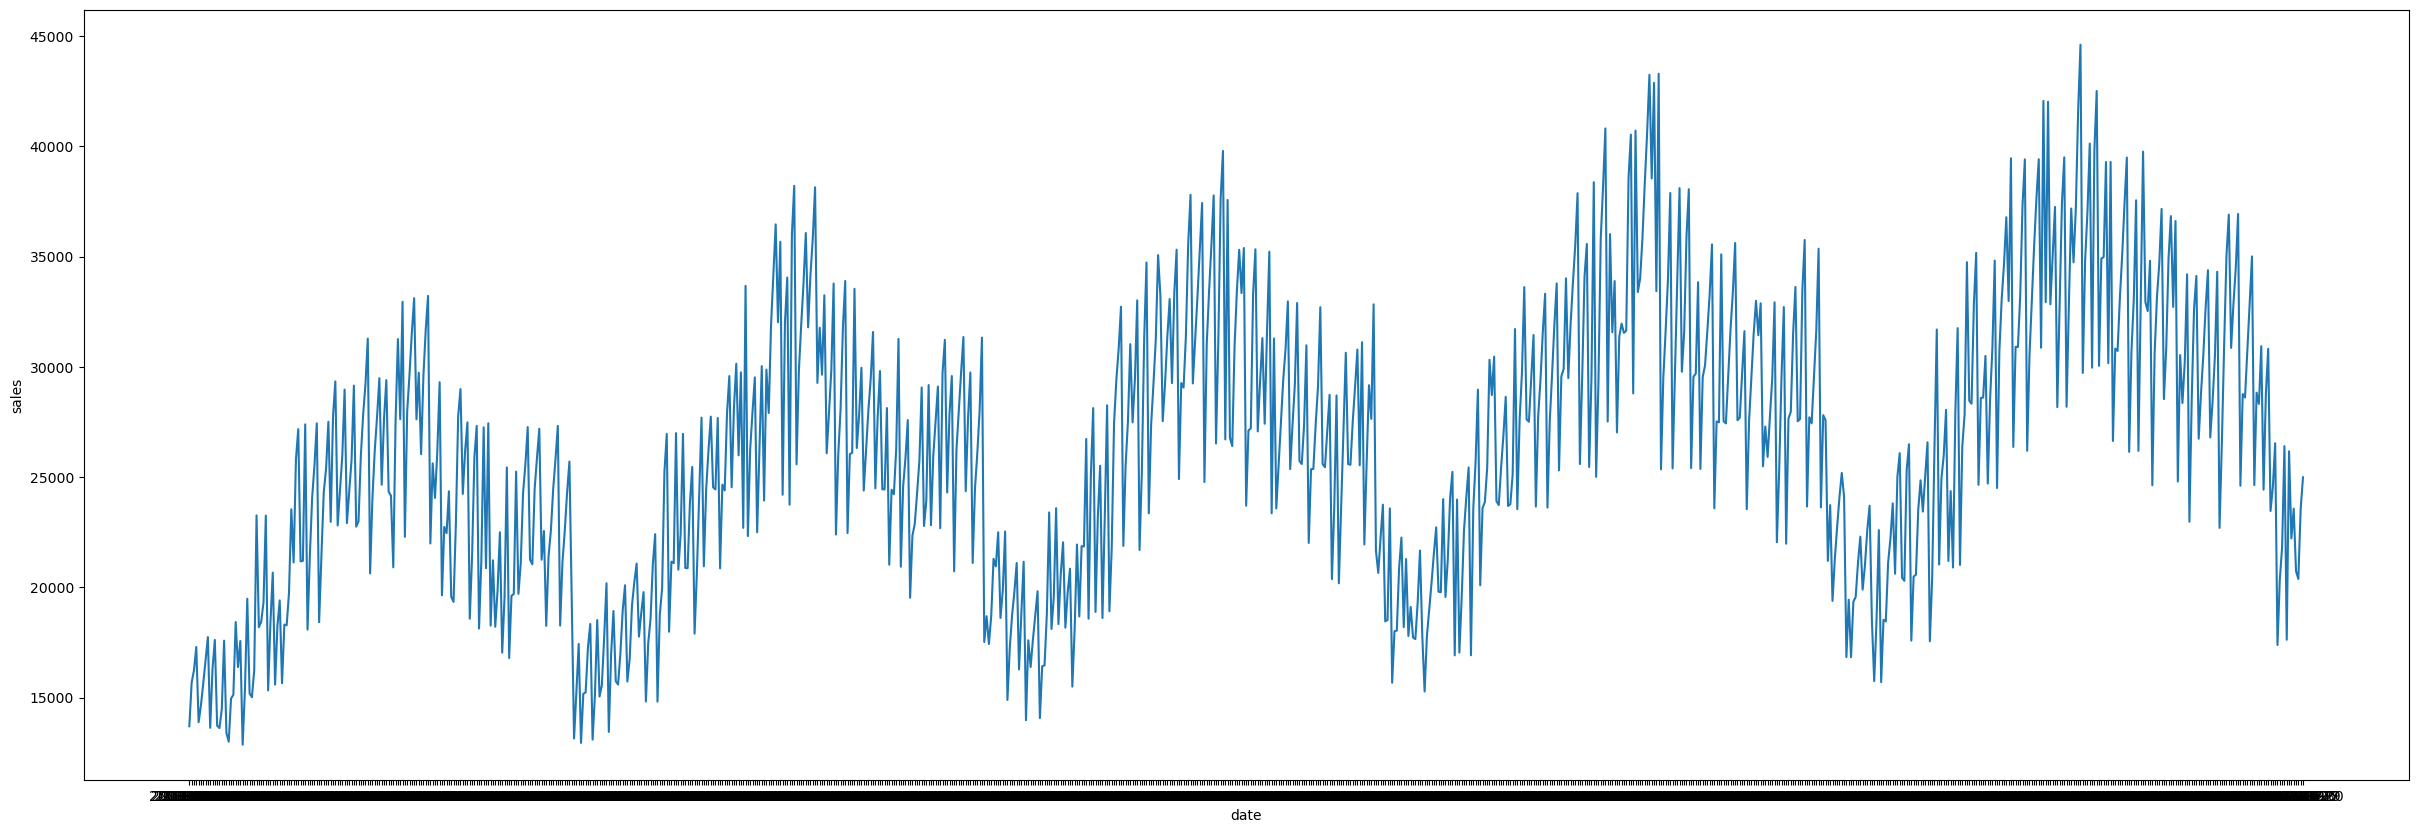

In [12]:
visualize_sales_date(daily_sales_df)

In [13]:
store_daily_sales_df = df.groupby(['date', 'store'], as_index=False).sales.sum()
store_daily_sales_df

,date,store,sales
0,2013-01-01,1,1316
1,2013-01-01,2,1742
2,2013-01-01,3,1588
3,2013-01-01,4,1423
4,2013-01-01,5,1032
...,...,...,...
18255,2017-12-31,6,2009
18256,2017-12-31,7,1831
18257,2017-12-31,8,3205
18258,2017-12-31,9,2774


store_id 1


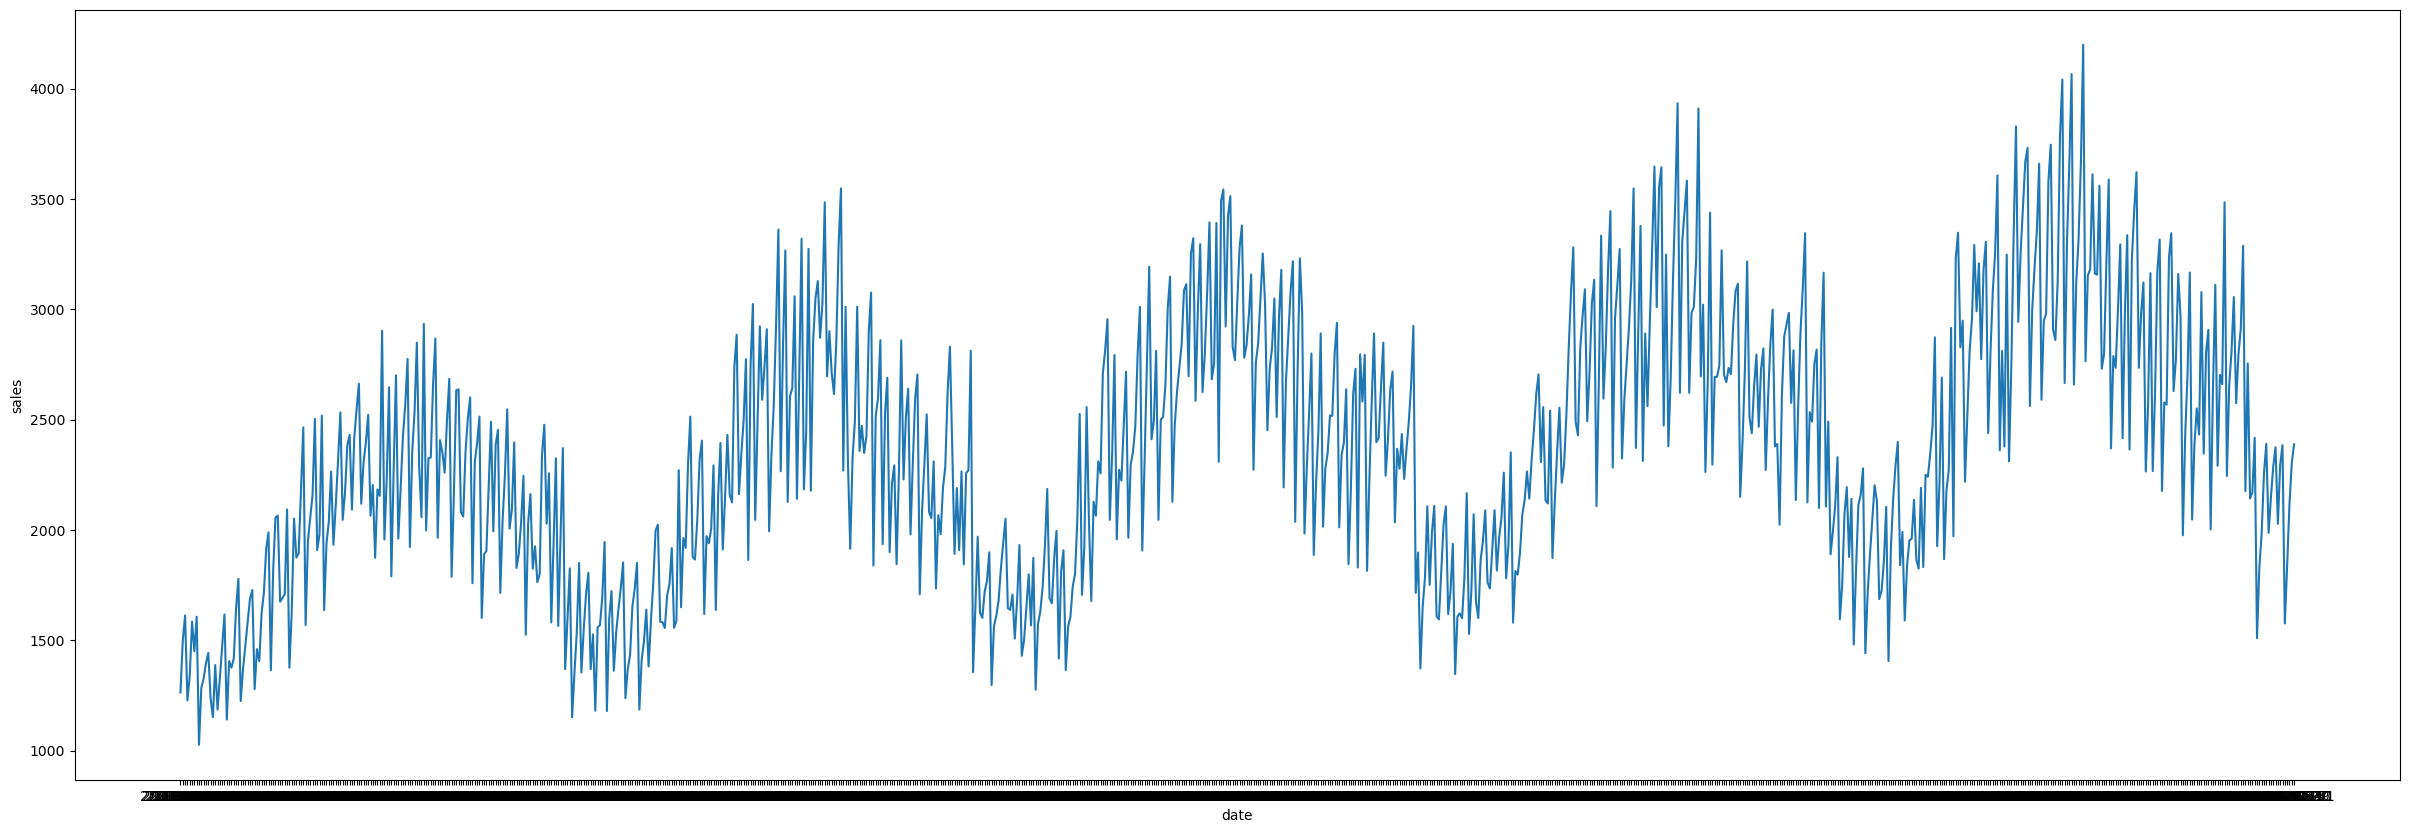

In [14]:
for store_id in df.store.unique():
    print('store_id', store_id)
    visualize_sales_date(
        store_daily_sales_df[store_daily_sales_df.store == store_id]
    )
    break

In [15]:
item_daily_sales_df = df.groupby(['date', 'item'], as_index=False).sales.sum()
item_daily_sales_df

,date,item,sales
0,2013-01-01,1,133
1,2013-01-01,2,327
2,2013-01-01,3,172
3,2013-01-01,4,102
4,2013-01-01,5,83
...,...,...,...
91295,2017-12-31,46,605
91296,2017-12-31,47,211
91297,2017-12-31,48,494
91298,2017-12-31,49,285


item_id 1


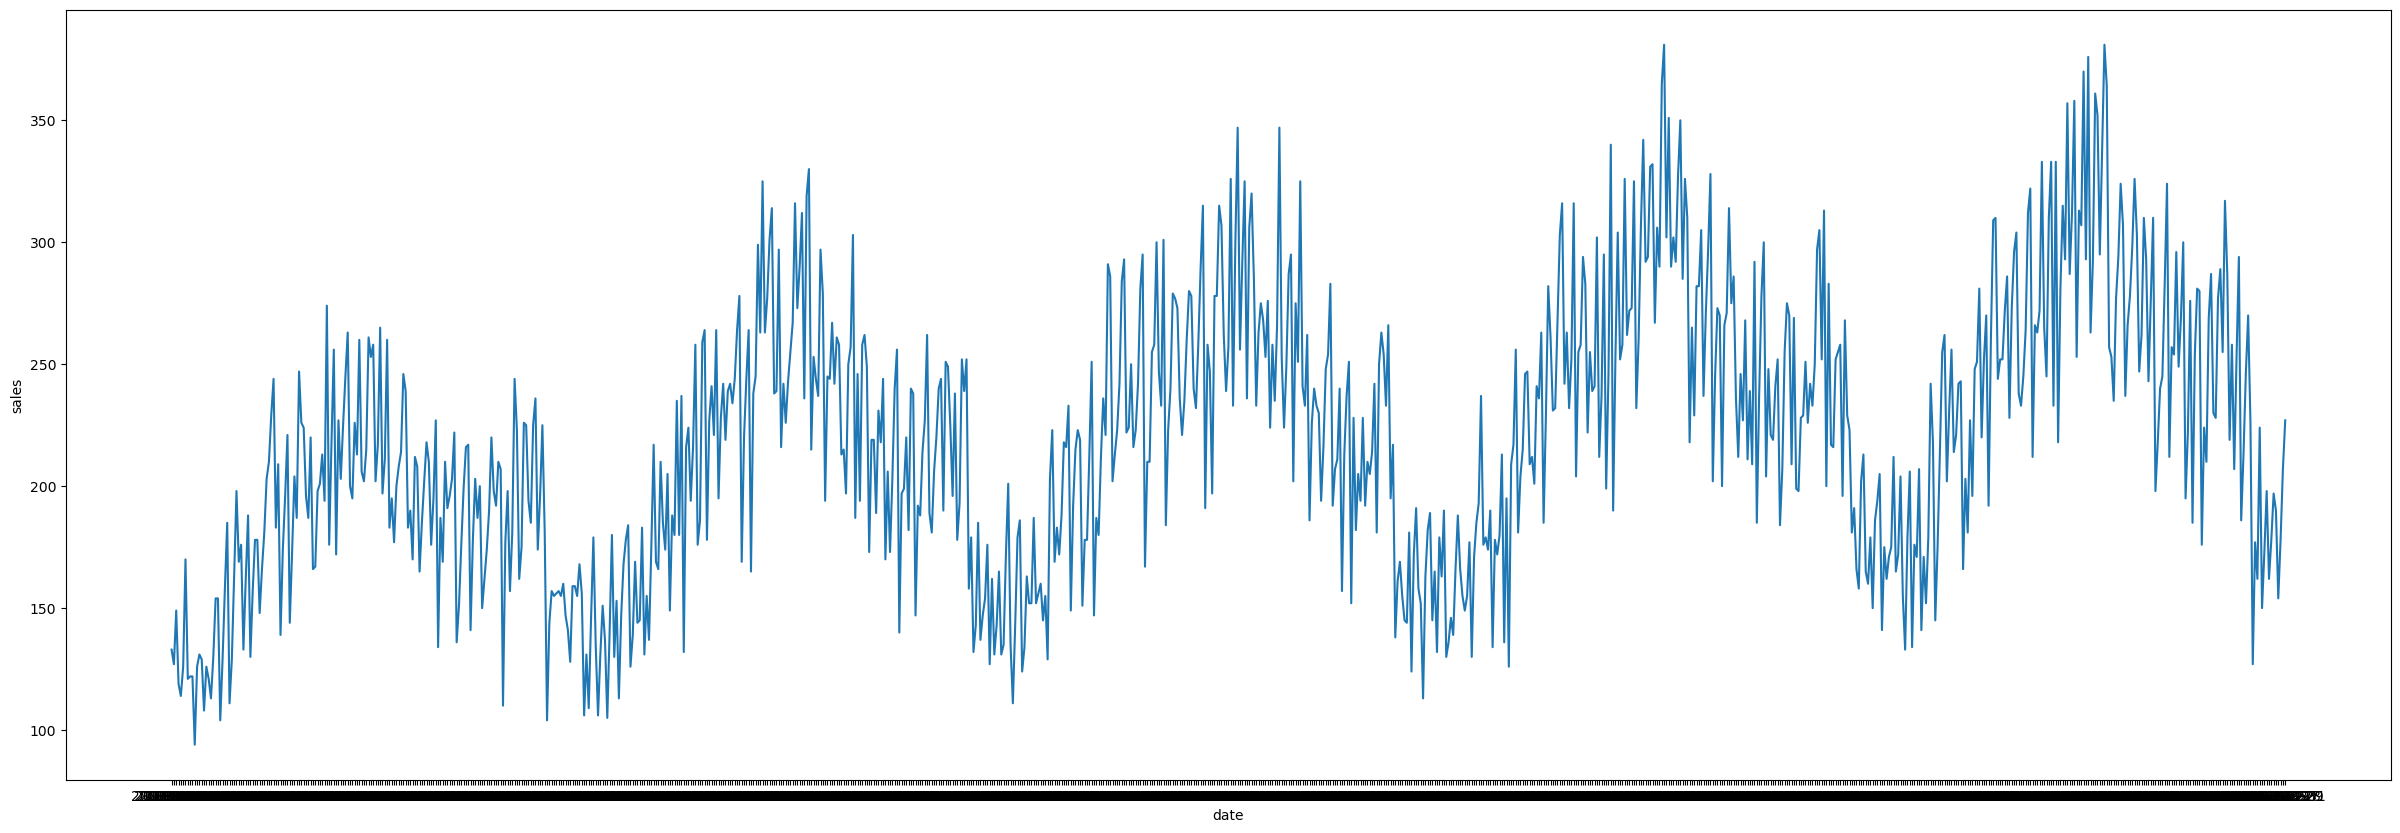

In [16]:
for item_id in df.item.unique():
    print('item_id', item_id)
    visualize_sales_date(
        item_daily_sales_df[item_daily_sales_df.item == 1]
    )
    break

## Prepare time series supervised label

In [17]:
df

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [18]:
# Group all data by store and item
# We solve time series problem of predicting sales of all items of all store
sales_df = df.groupby(by='date', as_index=False).agg({'sales': np.mean})
sales_df

,date,sales
0,2013-01-01,27.392
1,2013-01-02,27.356
2,2013-01-03,28.976
3,2013-01-04,31.354
4,2013-01-05,32.474
...,...,...
1821,2017-12-27,40.756
1822,2017-12-28,43.770
1823,2017-12-29,47.070
1824,2017-12-30,49.976


In [19]:
def series2supervised_label(series, window_size, lag_size):
    series_list, col_names = [], []
    for w in range(window_size + 1, 1, -1):
        series_list.append(series.shift(w))
        col_names.append(f't-{w - 2}' if w - 2 != 0 else 't')

    _df = pd.concat(series_list, axis=1)
    _df.columns = col_names

    return _df.dropna()

In [20]:
WINDOW_SIZE = 5
LAG_SIZE = 1

df_with_label = series2supervised_label(sales_df.sales, WINDOW_SIZE, LAG_SIZE)
df_with_label

,t-4,t-3,t-2,t-1,t
6,27.392,27.356,28.976,31.354,32.474
7,27.356,28.976,31.354,32.474,34.582
8,28.976,31.354,32.474,34.582,23.538
9,31.354,32.474,34.582,23.538,27.120
10,32.474,34.582,23.538,27.120,27.756
...,...,...,...,...,...
1821,44.428,47.134,49.526,52.260,35.034
1822,47.134,49.526,52.260,35.034,41.476
1823,49.526,52.260,35.034,41.476,40.756
1824,52.260,35.034,41.476,40.756,43.770


## Split training and validation set

In [21]:
VAL_PERCENT = 0.2

In [22]:
train_df = df_with_label.iloc[:int(1 - VAL_PERCENT * len(df_with_label))]
train_df

,t-4,t-3,t-2,t-1,t
6,27.392,27.356,28.976,31.354,32.474
7,27.356,28.976,31.354,32.474,34.582
8,28.976,31.354,32.474,34.582,23.538
9,31.354,32.474,34.582,23.538,27.120
10,32.474,34.582,23.538,27.120,27.756
...,...,...,...,...,...
1458,45.098,48.374,50.390,33.662,38.682
1459,48.374,50.390,33.662,38.682,39.120
1460,50.390,33.662,38.682,39.120,42.222
1461,33.662,38.682,39.120,42.222,44.592


In [23]:
x_train = train_df[['t-4', 't-3', 't-2', 't-1']]
y_train = train_df['t']

x_train.shape, y_train.shape

((1457, 4), (1457,))

In [24]:
val_df = df_with_label.iloc[int(1 - VAL_PERCENT * len(df_with_label)):]
val_df

,t-4,t-3,t-2,t-1,t
1463,39.120,42.222,44.592,47.584,47.418
1464,42.222,44.592,47.584,47.418,31.544
1465,44.592,47.584,47.418,31.544,37.300
1466,47.584,47.418,31.544,37.300,37.020
1467,47.418,31.544,37.300,37.020,39.790
...,...,...,...,...,...
1821,44.428,47.134,49.526,52.260,35.034
1822,47.134,49.526,52.260,35.034,41.476
1823,49.526,52.260,35.034,41.476,40.756
1824,52.260,35.034,41.476,40.756,43.770


In [25]:
x_val = val_df[['t-4', 't-3', 't-2', 't-1']]
y_val = val_df['t']

x_val.shape, y_val.shape

((363, 4), (363,))

# 2. Build and train model

## Build model

In [26]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(4, 1)),
    Dense(1)
])

2023-07-29 12:00:48.009345: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Compile model

In [27]:
mse_loss = MeanSquaredError()

In [28]:
opt = SGD(learning_rate=0.00001)

In [29]:
model.compile(loss=mse_loss, optimizer=opt)

## Train model

In [30]:
BATCH_SIZE = 64
NUM_EPOCH = 100

In [31]:
history = model.fit(
    x=np.expand_dims(x_train.values, -1),
    y=np.expand_dims(y_train.values, -1),
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCH,
    validation_data=(x_val, y_val),
    shuffle=True,
    validation_batch_size=BATCH_SIZE * 2,
)

Epoch 1/100
23/23 [==============================] - 3s 25ms/step - loss: 385.8258 - val_loss: 106.0459
Epoch 2/100
23/23 [==============================] - 0s 9ms/step - loss: 76.7301 - val_loss: 93.5242
Epoch 3/100
23/23 [==============================] - 0s 8ms/step - loss: 74.1298 - val_loss: 89.1712
Epoch 4/100
23/23 [==============================] - 0s 8ms/step - loss: 70.8904 - val_loss: 93.1727
Epoch 5/100
23/23 [==============================] - 0s 8ms/step - loss: 69.7411 - val_loss: 86.8493
Epoch 6/100
23/23 [==============================] - 0s 6ms/step - loss: 66.9365 - val_loss: 89.1804
Epoch 7/100
23/23 [==============================] - 0s 8ms/step - loss: 68.9335 - val_loss: 96.5796
Epoch 8/100
23/23 [==============================] - 0s 7ms/step - loss: 68.4898 - val_loss: 84.4740
Epoch 9/100
23/23 [==============================] - 0s 7ms/step - loss: 66.9234 - val_loss: 85.8812
Epoch 10/100
23/23 [==============================] - 0s 10ms/step - loss: 65.6517 - val

23/23 [==============================] - 0s 6ms/step - loss: 59.0776 - val_loss: 80.5047
Epoch 82/100
23/23 [==============================] - 0s 5ms/step - loss: 58.0569 - val_loss: 81.5785
Epoch 83/100
23/23 [==============================] - 0s 5ms/step - loss: 58.4155 - val_loss: 76.2158
Epoch 84/100
23/23 [==============================] - 0s 5ms/step - loss: 58.5544 - val_loss: 83.2403
Epoch 85/100
23/23 [==============================] - 0s 4ms/step - loss: 58.5830 - val_loss: 80.3360
Epoch 86/100
23/23 [==============================] - 0s 5ms/step - loss: 58.2759 - val_loss: 79.1527
Epoch 87/100
23/23 [==============================] - 0s 4ms/step - loss: 58.2134 - val_loss: 75.4762
Epoch 88/100
23/23 [==============================] - 0s 4ms/step - loss: 57.7703 - val_loss: 75.5656
Epoch 89/100
23/23 [==============================] - 0s 4ms/step - loss: 58.2323 - val_loss: 76.5550
Epoch 90/100
23/23 [==============================] - 0s 6ms/step - loss: 57.9260 - val_loss: 8

# 3. Evaluate model

In [32]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

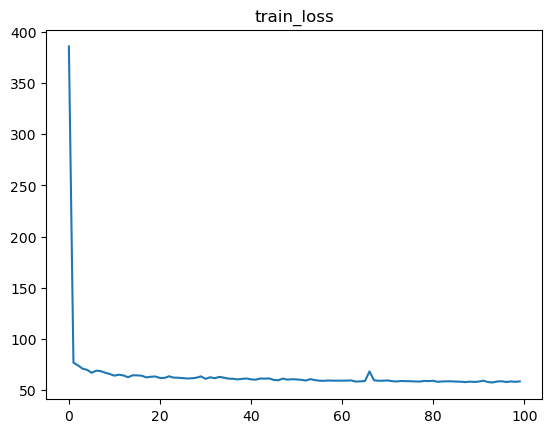

In [33]:
log_loss(range(NUM_EPOCH), history.history['loss'], 'train_loss')

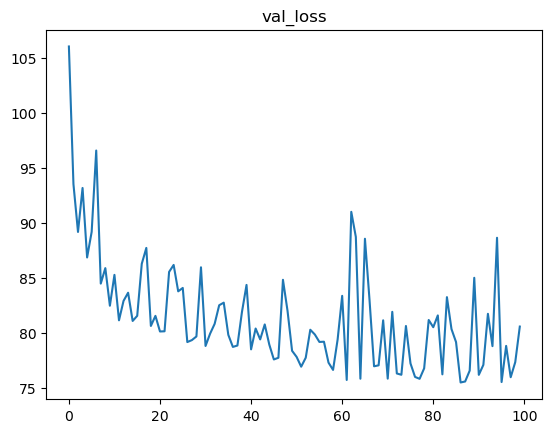

In [34]:
log_loss(range(NUM_EPOCH), history.history['val_loss'], 'val_loss')

# 4. Predict new data

In [35]:
y_pred = model.predict(x_val)
y_pred.shape

12/12 [==============================] - 0s 2ms/step


(363, 1)

In [36]:
x_val['t-1']

1463    47.584
1464    47.418
1465    31.544
1466    37.300
1467    37.020
         ...  
1821    52.260
1822    35.034
1823    41.476
1824    40.756
1825    43.770
Name: t-1, Length: 363, dtype: float64

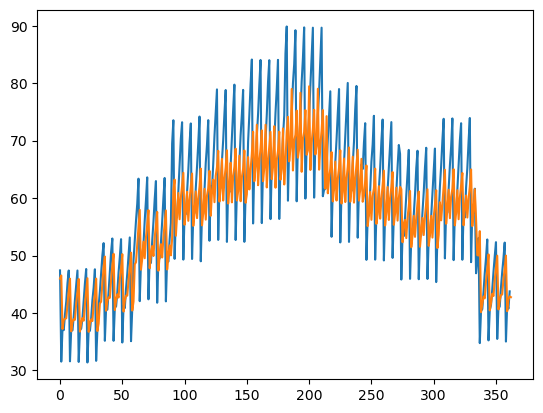

In [37]:
plt.plot(list(range(362)), x_val['t-1'][1:])
plt.plot(list(range(363)), y_pred)
plt.show()